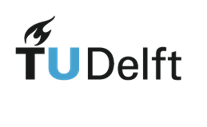




<div style="text-align: center">CIEM5110 â€“ unit 3 â€“ Measurement and Analysis of Vibrations<br>
    Assignment report : <b>Experimental modal analysis of a suspended beam</b></div>


<div style="text-align: center"><b>Deadline</b>: 11 April 2025, 23:59 hrs</div>

***

# Group # (fill in your group number)

**Names**

**Student numbers**


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
import math

# Problem set 1: signal processing

### Exercise 1.1. Time domain signals
**a**. Plot the hammer force $F_2$ in the time domain and indicate two artefacts in the plot.

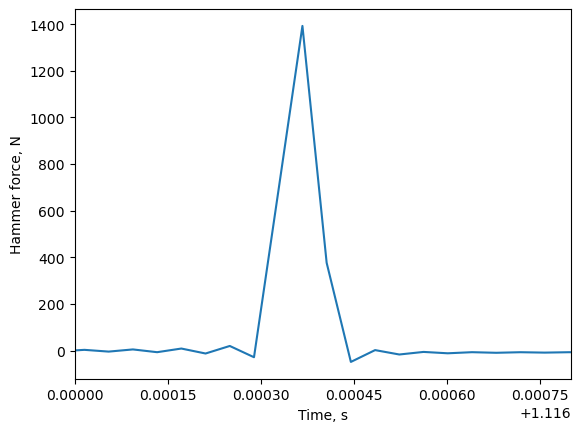

In [24]:
# import data form csv file
data_acc2T1 = pd.read_csv('data1/acc2T1.csv', skiprows=3).to_numpy()
data_acc2T2 = pd.read_csv('data1/acc2T2.csv', skiprows=3).to_numpy()
data_acc2T3 = pd.read_csv('data1/acc2T3.csv', skiprows=3).to_numpy()
data_acc2T4 = pd.read_csv('data1/acc2T4.csv', skiprows=3).to_numpy()
data_acc2T5 = pd.read_csv('data1/acc2T5.csv', skiprows=3).to_numpy()

t_F2 = np.column_stack([
    data_acc2T1[:, 0],
    data_acc2T2[:, 0],
    data_acc2T3[:, 0],
    data_acc2T4[:, 0],
    data_acc2T5[:, 0],
])
F_2 = np.column_stack([
    data_acc2T1[:, 1],
    data_acc2T2[:, 1],
    data_acc2T3[:, 1],
    data_acc2T4[:, 1],
    data_acc2T5[:, 1],
])

# Plot F_2 vs time
plt.plot(t_F2[:, 0], F_2[:, 0], label='T1')
plt.xlabel('Time, s')
import matplotlib.ticker as ticker
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(0.00015))


plt.ylabel('Hammer force, N')
plt.xlim(1.116 , 1.1168) # use plt.xlim and plt.ylim to control the plot region to identify possible artefacts
plt.show()

**The first artefact is small oscillations appear before and after the main peak, the second artefact is the impact force has a time duration, which are not ideal for a hammer force signal.**


**b**. What is the duration of the impulse $F_2$? What is the approximate frequency range that can be well excited by this force based on this impulse duration? 

In [25]:
t_impact = 0.00045 -0.00029
f_max = 1/t_impact

print(f"the time duration of the impact is {t_impact:.6f} s")
print(f"the maximum frequency that can be captured is {f_max:.2f} Hz")

the time duration of the impact is 0.000160 s
the maximum frequency that can be captured is 6250.00 Hz


**The frequency range is up to 6250Hz.**

**c**. Plot the five repeated impact forces for $F_2$. Identify the two impacts with the maximum and minimum peak forces among the five, denoted as $F_{2,max}$ and $F_{2,min}$, respectively. Plot the acceleration $a_{22}$ for these two impacts, denoated as $a_{22,max}$ and $a_{22,min}$, respectively.What are the main differences between the two acceleration signals and why?

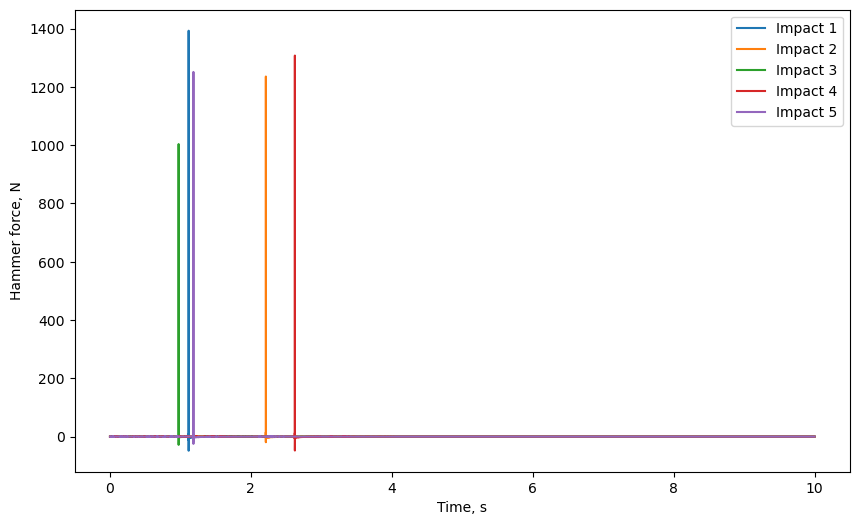

impact 1 is the largest with a maximum force of 1392.52 Nand impact 3 is the smallest with a maximum force of 1003.66 N


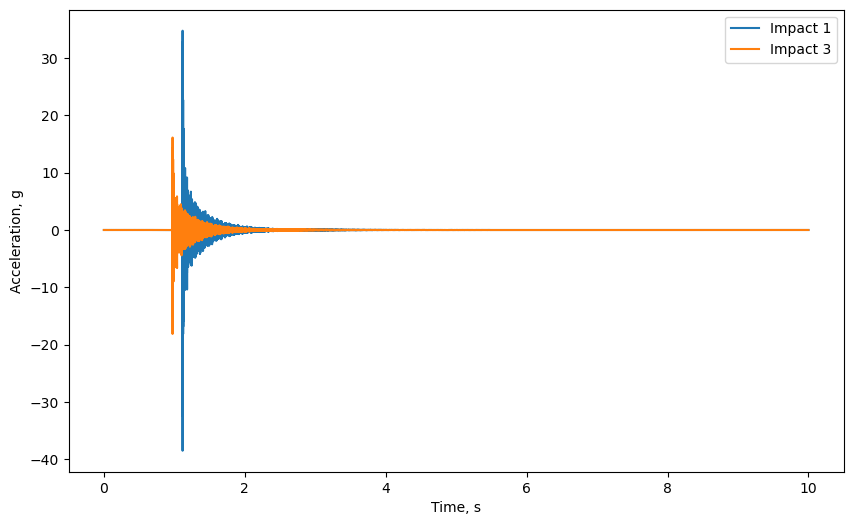

In [26]:

# Plot F_2 vs time for all 5 impacts
plt.figure(figsize=(10, 6))
for i in range(5):
    plt.plot(t_F2[:, i], F_2[:, i], label=f'Impact {i+1}')
plt.xlabel('Time, s')
plt.ylabel('Hammer force, N')
plt.legend()

plt.show()

# impact 3 is the smallest and impact 1 is the largest
print(
    f"impact 1 is the largest with a maximum force of {np.max(F_2[:, 0]):.2f} N"       
    f"and impact 3 is the smallest with a maximum force of {np.max(F_2[:, 2]):.2f} N"
      )
acc2 = np.column_stack([
    data_acc2T1[:, 5],
    data_acc2T2[:, 5],
    data_acc2T3[:, 5],
    data_acc2T4[:, 5],
    data_acc2T5[:, 5],
])
t_acc2 = np.column_stack([
    data_acc2T1[:, 4],
    data_acc2T2[:, 4],
    data_acc2T3[:, 4],
    data_acc2T4[:, 4],
    data_acc2T5[:, 4],
])

# Plot acc2 vs time for impact 1 and impact 3
plt.figure(figsize=(10, 6))
plt.plot(t_acc2[:, 0], acc2[:, 0], label='Impact 1')
plt.plot(t_acc2[:, 2], acc2[:, 2], label='Impact 3')
plt.xlabel('Time, s')
plt.ylabel('Acceleration, g')
plt.legend()

plt.show()


**The main differences between the two acceleration signals are that the maximum impact force generates more energy, resulting in a higher amplitude and longer vibration duration in the acceleration signal compared to the minimum impact force.**

### Exercise 1.2. Fourier transform and power spectral density (PSD)
**a**. Plot the positive part of the double-sided Fourier amplitude spectrums of the five forces in one figure in log-log scale. Explain the similarities and differences between different force spectrums.

C:\Users\shuse\AppData\Local\Temp\ipykernel_30864\2167341004.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


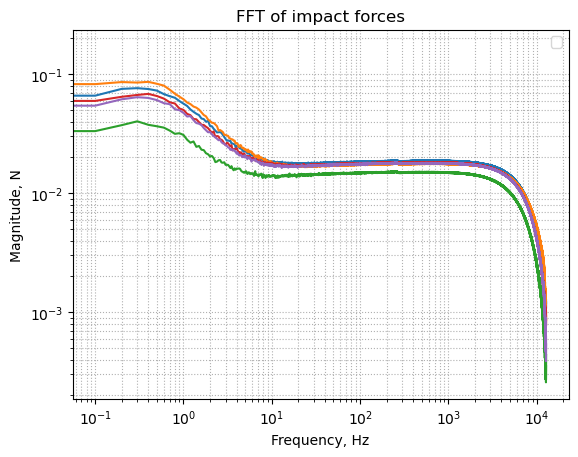

In [27]:


sf = 25600
N_sig = F_2.shape[0] # number of data points in the signal
freq = fftfreq(N_sig, 1/sf)[:N_sig//2] # fourier frequencies

# Calculate the fft of each force and plot them in one figure
plt.figure
for ii in range(5):
    fft_force = fft(F_2[:,ii],axis = -1)
    # plot the positive part of the fourier spectrum in log-log scale
    plt.loglog(freq, 2.0/N_sig * np.abs(fft_force[0:N_sig//2]))

# plt.xlim(10, 10000)
plt.xlabel('Frequency, Hz')
plt.ylabel('Magnitude, N')
plt.title('FFT of impact forces')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.show()



**For the five forces, they show similar trends because of the similar mechanisms at each play. The amplitude remains relatively constant at frequencies below 1 Hz, decreases in the range of 1–10 Hz, becomes stable again between 10 and 5000 Hz, after the frequency around 6250Hz, the amplitude drops sharply beyond 10,000 Hz. This is because the hammer impact is very short in duration, and most of the energy is concentrated in the low-frequency range. Differences between the spectra are mainly in amplitude due to the varying input forces.**

**b**. List the first three natural frequencies calculated by the analytical model.

In [28]:
# Rail properties
E = 210e9          # Young's modulus [Pa]
rho = 7850         # Density [kg/m^3]
I = 2337.9e-8      # Moment of inertia [m^4]   (2337.9 cm^4 -> m^4)
A = 69.77e-4       # Cross-sectional area [m^2] (69.77 cm^2 -> m^2)

# Measured beam length
L = 3.0            # [m] beam length

# Free-free beam values: beta_n * L
betaL = np.array([4.730041, 7.853205, 10.995608])

# beta_n
beta = betaL / L

# Natural frequencies in rad/s
omega_n = (betaL**2) * np.sqrt(E * I / (rho * A * L**4))

# Natural frequencies in Hz
f_n = omega_n / (2 * np.pi)

print("Natural frequencies (rad/s):", omega_n)
print("Natural frequencies (Hz):", f_n)

for i, f in enumerate(f_n, start=1):
    print(f"Mode {i}: {f:.2f} Hz")


Natural frequencies (rad/s): [ 744.28749782 2051.65712316 4022.06801763]
Natural frequencies (Hz): [118.45703436 326.53137268 640.13200646]
Mode 1: 118.46 Hz
Mode 2: 326.53 Hz
Mode 3: 640.13 Hz


**c**. Calculate the Fourier transform of $a_{22,max}$ and $a_{22,min}$. Plot the positive part of the double-sided Fourier amplitude spectrums of the two accelerations in one figure in log-log scale. Please use `plt.xlim` to zoom in to the frequency range that shows the first three natural frequencies. Explain the similarities and differences between the two spectrums.

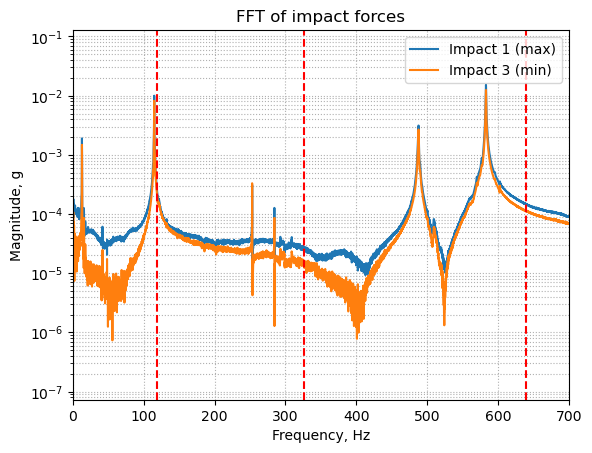

In [29]:
sf = 25600
N_sig = acc2.shape[0] # number of data points in the signal
freq = fftfreq(N_sig, 1/sf)[:N_sig//2] # fourier frequencies

# Calculate the fft of each force and plot them in one figure

fft_acc2 = []
for ii in range(5):
    fft_acc2.append(fft(acc2[:,ii],axis = -1))
    # plot the positive part of the fourier spectrum in log-log scale


plt.semilogy(freq, 2.0/N_sig * np.abs(fft_acc2[0][0:N_sig//2]), label='Impact 1 (max)')
plt.semilogy(freq, 2.0/N_sig * np.abs(fft_acc2[2][0:N_sig//2]), label='Impact 3 (min)')
plt.xlim(0, 700)

plt.xlabel('Frequency, Hz')
plt.ylabel('Magnitude, g')
plt.title('FFT of impact forces')
plt.legend()
plt.grid(True, which='both', ls=':')
# inlcude 3 natural frequencies in the plot
for f in f_n:
    plt.axvline(f, color='r', linestyle='--', label=f'Natural frequency: {f:.2f} Hz')
    

plt.show()

**Both spectra show three clear peaks at the same frequencies, which correspond to the natural frequencies of the beam. This indicates that the natural frequency is independent of the excitation. Between the peaks, antiresonances are observed, which are caused by the interaction of different vibration modes.**

**However, The amplitudes of the peaks differ between the two spectra, mainly due to the difference in the input force. Slight differences in the antiresonance frequencies are observed, which can be attributed to measurement noise.**

**d**. Calculate the Welch periodogram of the PSD of $a_{22,max}$. Plot the periodogram in log-log scale. 

- Please use `plt.xlim` to zoom in to the frequency range that shows the first three natural frequencies.

- Use a rectangular window with different lengths to see its effect. (set the argument `nperseg` with different values)

- Compare the Welch periodogram  and Fourier spectrum of $a_{22,max}$,and explain the main differences between the two.

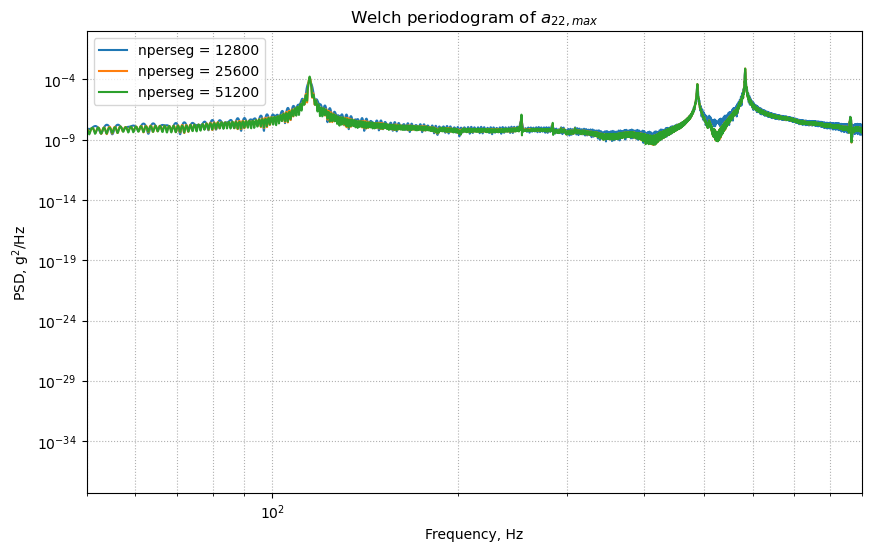

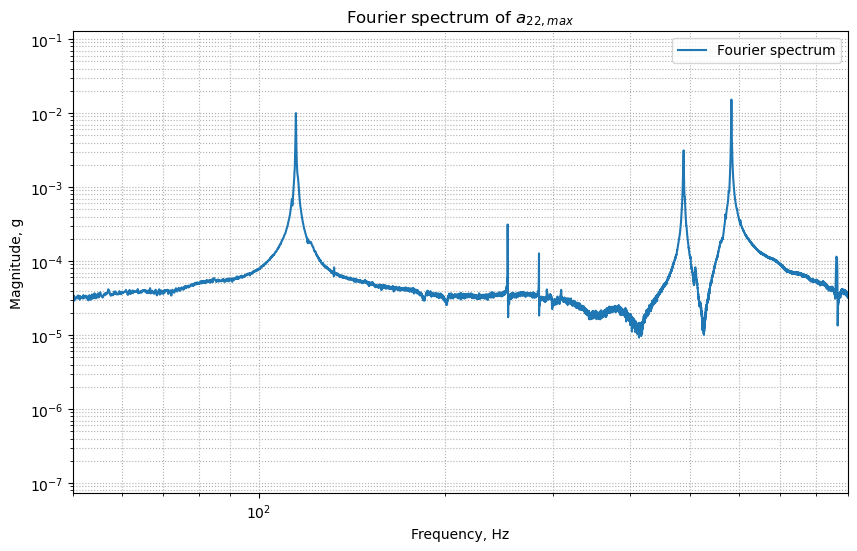

In [30]:
# a22,max from the impact with the largest peak force
peak_forces = np.max(F_2, axis=0)
max_idx = np.argmax(peak_forces)
a22_max = acc2[:, max_idx]

sf = 25600
N_sig = a22_max.shape[0]
N_fft = N_sig
N_overlap = 0

# Different rectangular window lengths
window_lengths = [N_sig // 20, N_sig // 10, N_sig // 5]

plt.figure(figsize=(10, 6))
for N_window in window_lengths:
    fxx, pxx = signal.welch(
        a22_max,
        sf,
        window='boxcar',
        nperseg=N_window,
        noverlap=N_overlap,
        nfft=N_fft
    )
    plt.loglog(fxx, pxx, label=f'nperseg = {N_window}')

plt.xlim(50, 900)   # adjust to show your first 3 natural frequencies
plt.xlabel('Frequency, Hz')
plt.ylabel('PSD, g$^2$/Hz')
plt.title(r'Welch periodogram of $a_{22,max}$')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.show()

fft_acc = fft(a22_max)
freq = fftfreq(N_sig, 1 / sf)[:N_sig // 2]
amp_fft = 2.0 / N_sig * np.abs(fft_acc[:N_sig // 2])

plt.figure(figsize=(10, 6))
plt.loglog(freq[1:], amp_fft[1:], label='Fourier spectrum')
plt.xlim(50, 900)
plt.xlabel('Frequency, Hz')
plt.ylabel('Magnitude, g')
plt.title(r'Fourier spectrum of $a_{22,max}$')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.show()


**Comparing the two plots, it can be observed that peaks appear at the same frequency locations in both spectra, and antiresonances can be identified between the peaks. In addition, the amplitude units are different: the Welch spectrum represents the power spectral density (g^2/Hz), while the Fourier spectrum represents the amplitude (g).**

**The main difference between the two is the sharpness of the peaks. The peaks in the Welch spectrum are less sharp than those in the Fourier spectrum. This is because the Welch method divides the signal into multiple segments and computes the FFT of each segment before averaging, whereas the Fourier spectrum is obtained by directly applying the FFT to the entire signal. As a result, the Welch method reduces the frequency resolution, making the peak frequencies less clearly defined compared to the Fourier spectrum.**

### Exercise 1.3. Signal alignment, windowing and zero-padding

**a. (Force window)** Choose one impact force, apply a force window, and plot the windowed and orginal signals in the same figure to show the differences.

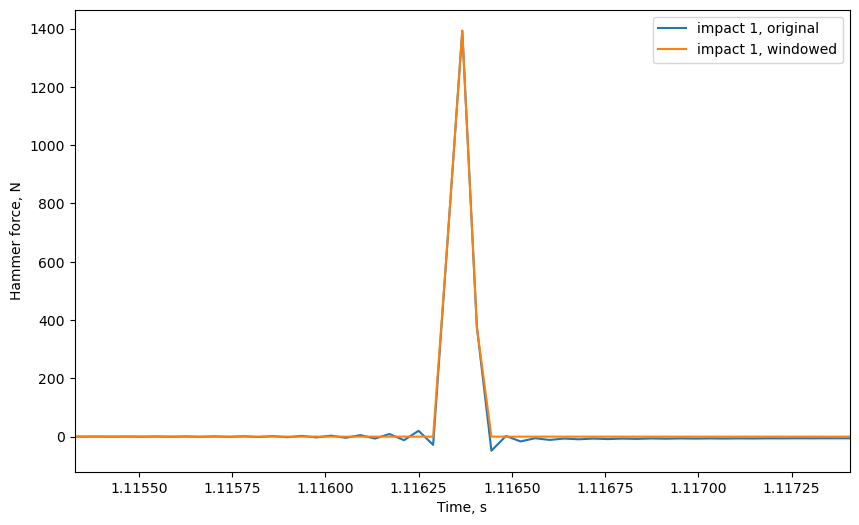

In [31]:
# Find the impacts with maximum and minimum peak force
peak_forces = np.max(F_2, axis=0)
max_idx = np.argmax(peak_forces)
min_idx = np.argmin(peak_forces)

# Use F_2,max as the example impact
force_signal = F_2[:, max_idx]
time_signal = t_F2[:, max_idx]

# Define a trigger force
force_trigger = 50

# Get the boolean indices of the forces larger than the trigger force
idx_boolean = force_signal > force_trigger

# Find the indices of triggered forces
idx_triggered = np.where(idx_boolean)[0]

# Define a rectangular window
rec_win = np.zeros(len(force_signal))
rec_win[idx_triggered] = 1

# Apply the force window
f_max_windowed = np.multiply(force_signal, rec_win)

# Plot the forces
plt.figure(figsize=(10, 6))
plt.plot(time_signal, force_signal, label=f'impact {max_idx+1}, original')
plt.plot(time_signal, f_max_windowed, label=f'impact {max_idx+1}, windowed')
plt.xlabel('Time, s')
plt.ylabel('Hammer force, N')
plt.xlim((time_signal[idx_triggered[0]] - 0.001, time_signal[idx_triggered[-1]] + 0.001))
# plt.ylim((-20, 100))
plt.legend()
plt.show()


**b. (Signal alignment)** In Exercise 1.1.c, we showed that the forces and accelerations for different impacts are not aligned in the time domain. To align the signals, you can truncate each force signal from a few (e.g., 10) samples before the index of the first triggered force. Show the aligned force and acceleration sigals.Please use $F_{2,max}$ ($a_{22,max}$) and $F_{2,min}$ ($a_{22,min}$) as examples.

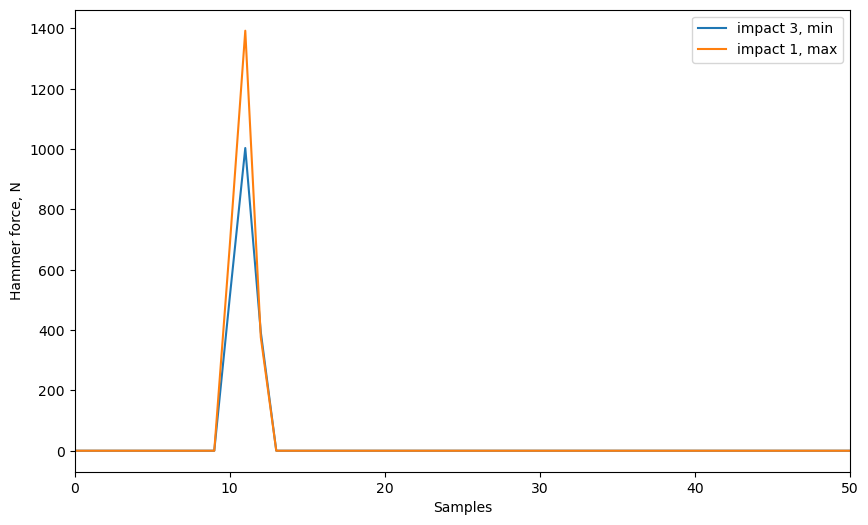

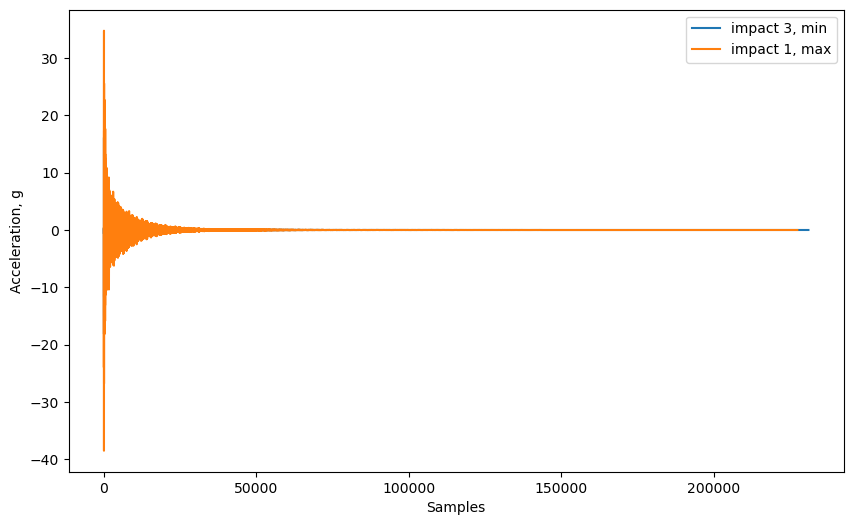

In [32]:
# Truncate the max signal 10 samples before the first triggered index
force_max = F_2[:, max_idx]
acc_max = acc2[:, max_idx]

idx_boolean = force_max > force_trigger
idx_triggered = np.where(idx_boolean)[0]

rec_win = np.zeros(len(force_max))
rec_win[idx_triggered] = 1
f_max_windowed = np.multiply(force_max, rec_win)

f_max_truncated = f_max_windowed[idx_triggered[0]-10:]
acc_max_truncated = acc_max[idx_triggered[0]-10:]

# Do the same for the minimum peak impact
force_min = F_2[:, min_idx]
acc_min = acc2[:, min_idx]

idx_boolean = force_min > force_trigger
idx_triggered = np.where(idx_boolean)[0]

rec_win = np.zeros(len(force_min))
rec_win[idx_triggered] = 1
f_min_windowed = np.multiply(force_min, rec_win)

f_min_truncated = f_min_windowed[idx_triggered[0]-10:]
acc_min_truncated = acc_min[idx_triggered[0]-10:]

# Plot the two aligned forces
plt.figure(figsize=(10, 6))
plt.plot(f_min_truncated, label=f'impact {min_idx+1}, min')
plt.plot(f_max_truncated, label=f'impact {max_idx+1}, max')
plt.xlabel('Samples')
plt.ylabel('Hammer force, N')
plt.xlim((0, 50))
plt.legend()
plt.show()

# Plot the two aligned accelerations
plt.figure(figsize=(10, 6))
plt.plot(acc_min_truncated, label=f'impact {min_idx+1}, min')
plt.plot(acc_max_truncated, label=f'impact {max_idx+1}, max')
plt.xlabel('Samples')
plt.ylabel('Acceleration, g')
plt.legend()
plt.show()


**c. (Exponential window)**. Apply an exponential window to aligned $a_{22,max}$.The exponential window can be calculated as $w(t)=e^{(-\beta t)}$. Compare the windowed and orignal signals with different $\beta$ values. Explain why an exponential window is necessry and what its effect for the modal analysis later on.

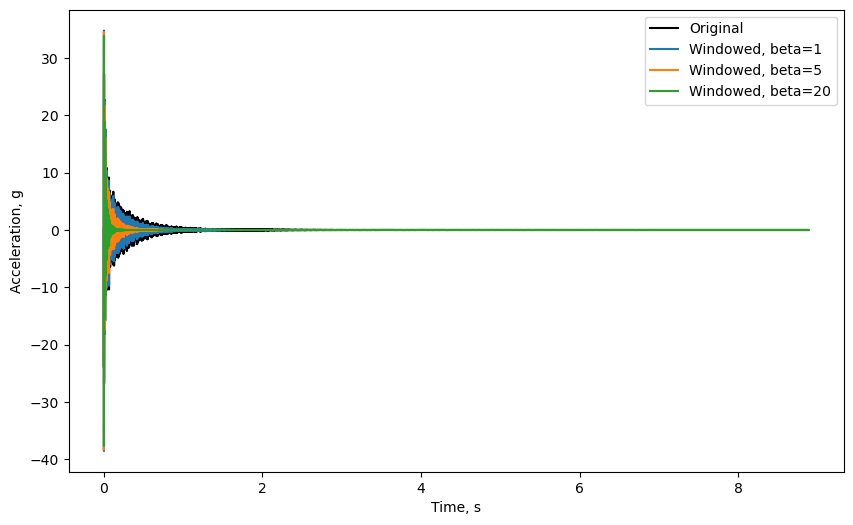

In [33]:
# Create time instances for the aligned acceleration
sf = 25600
t_acc = np.arange(len(acc_max_truncated)) / sf

# Try different beta values
beta_list = [1, 5, 20]

plt.figure(figsize=(10, 6))
plt.plot(t_acc, acc_max_truncated, label='Original', color='k', linewidth=1.5)

for beta in beta_list:
    exp_win = np.exp(-beta * t_acc)
    acc_max_windowed = np.multiply(acc_max_truncated, exp_win)
    plt.plot(t_acc, acc_max_windowed, label=f'Windowed, beta={beta}')

plt.xlabel('Time, s')
plt.ylabel('Acceleration, g')
plt.legend()
plt.show()


**d. (Zero-padding)** Caculate the Welch periodogram of the windowed $a_{22,max}$.This time zero-pad the signal to 40 seconds by setting the `nfft` argument in `signal.welch` to the correct value. Please use `plt.xlim` to zoom in to the frequency range that shows the first three natural frequencies. Compare this periodogram with the one in Exercise 1.2.d. What are the main differences and why?

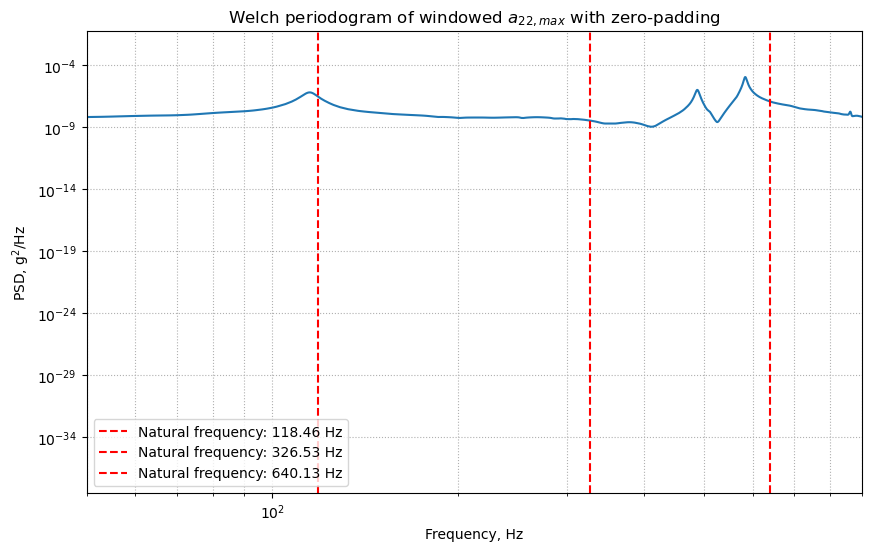

In [34]:
N_fft = 40 * sf                  # zero-pad to 40 seconds
N_overlap = 0                    # no overlap
N_window = len(acc_max_windowed) # window length = signal length

# Calculate the Welch estimate using a rectangular window
fxx, pxx = signal.welch(
    acc_max_windowed,
    sf,
    window='boxcar',
    nperseg=N_window,
    noverlap=N_overlap,
    nfft=N_fft
)

# Plot
plt.figure(figsize=(10, 6))
plt.loglog(fxx, pxx)
plt.xlim(50, 900)   # adjust if needed for your first 3 natural frequencies
plt.xlabel('Frequency, Hz')
plt.ylabel('PSD, g$^2$/Hz')
plt.title(r'Welch periodogram of windowed $a_{22,max}$ with zero-padding')

# inlcude 3 natural frequencies in the plot
for f in f_n:
    plt.axvline(f, color='r', linestyle='--', label=f'Natural frequency: {f:.2f} Hz')

plt.grid(True, which='both', ls=':')
plt.legend()
plt.show()


# Problem set 2: frequency response functions (FRF)

###  Exercise 2.1. H1 estimator of FRF

**a**. Plot the processed input (force) signal and output (acceleration) signal.

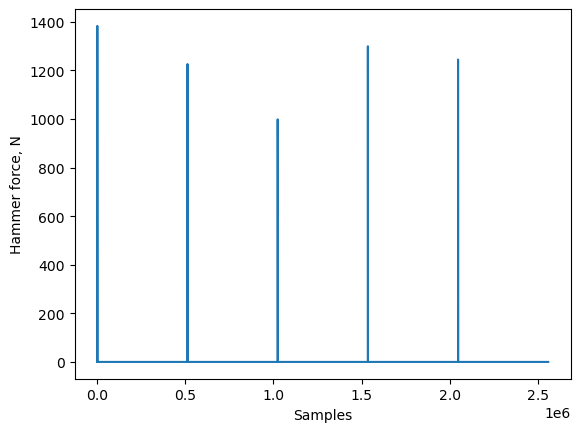

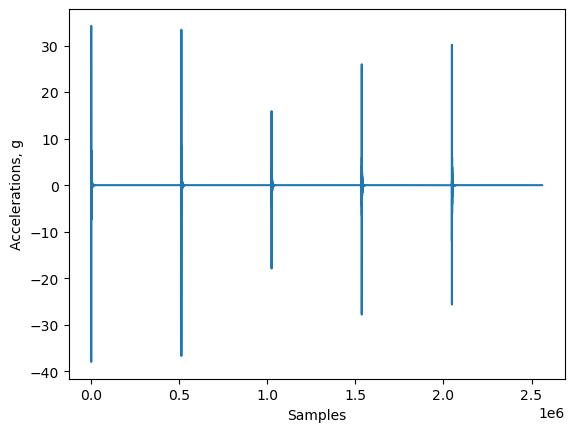

In [35]:
forces = F_2
accs = acc2


# Define a trigger force of 5 N
force_trigger = 5

# Define a matrix to store 20 s long signal for five impacts
acc_pad = np.zeros((20 * sf,5))
impulse_pad = np.zeros((20 * sf,5))

# Loop through each impact
for ii in range(5):
    # Get one impact
    impulse = forces[:,ii]
    acc = accs[:,ii]
    
    # Truncate the signals
    idx_boolean = impulse > force_trigger
    idx_triggered = np.where(idx_boolean)[0]
    rec_win = np.zeros(len(impulse))
    rec_win[idx_triggered,] = 1
    impulse_windowed = np.multiply(impulse, rec_win)
    impulse_truncated = impulse_windowed[idx_triggered[0]-10:,]
    acc_truncated = acc[idx_triggered[0]-10:,]

    # Create time instances for the window
    t_acc = np.arange(len(acc_truncated)) / sf

    # Create the exponential window
    beta = 10
    exp_win = np.exp(-beta * t_acc)

    # Apply the exponential window
    acc_windowed = np.multiply(acc_truncated, exp_win)
    impulse_truncated_exp = np.multiply(impulse_truncated, exp_win)


    # Zero-pad the signals to 20 s long
    pad_after = 20 * sf - len(acc_truncated)
    acc_pad[:,ii] = np.pad(acc_windowed,(0,pad_after),'constant',constant_values = (0,0))
    impulse_pad[:,ii] = np.pad(impulse_truncated_exp,(0,pad_after),'constant',constant_values = (0,0))

# Rearrange the force signals in one array and acceleration signals in one array
acc_processed = np.hstack((acc_pad[:,0],acc_pad[:,1],acc_pad[:,2],acc_pad[:,3],acc_pad[:,4]))
impulse_processed = np.hstack((impulse_pad[:,0],impulse_pad[:,1],impulse_pad[:,2],impulse_pad[:,3],impulse_pad[:,4]))

# Plot the results
plt.figure
plt.plot(impulse_processed)
plt.xlabel('Samples')
plt.ylabel('Hammer force, N')
plt.show()

plt.figure
plt.plot(acc_processed)
plt.xlabel('Samples')
plt.ylabel('Accelerations, g')
plt.show()


**b**. Calculate the PSD, CSD and H1 estimator of the FRF ($\hat{H}_{22}(\omega)$) using the processed input (force) signals and output (acceleration) signals.Plot the amplitude and phase angle of ($\hat{H}_{22}(\omega)$).

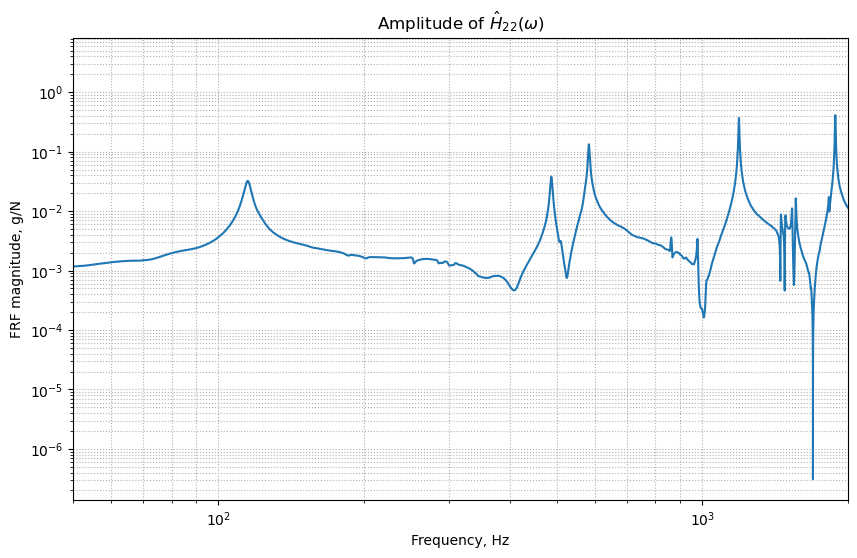

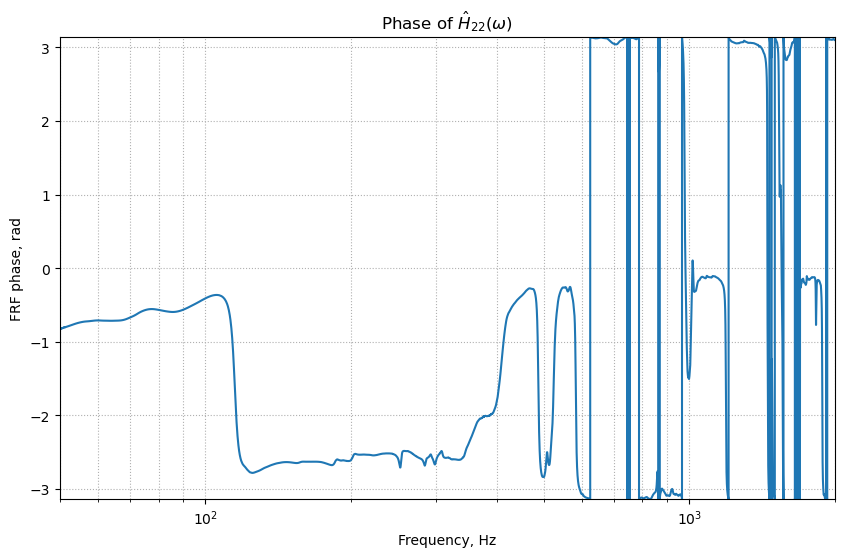

In [36]:
N_fft = 80 * sf      # zero-pad to 80 seconds
N_overlap = 0        # no overlap
N_window = 20 * sf   # window length = padded signal length

# Calculate PSD and CSD using Welch's method
fxx, Sxx = signal.welch(
    impulse_processed,
    sf,
    window='boxcar',
    nperseg=N_window,
    noverlap=N_overlap,
    nfft=N_fft
)

fxy, Sxy = signal.csd(
    impulse_processed,
    acc_processed,
    sf,
    window='boxcar',
    nperseg=N_window,
    noverlap=N_overlap,
    nfft=N_fft
)

# H1 estimator
H1_22 = np.divide(Sxy, Sxx)

# Plot FRF amplitude
plt.figure(figsize=(10, 6))
plt.loglog(fxx, np.abs(H1_22))
plt.xlim(50, 2000)
plt.xlabel('Frequency, Hz')
plt.ylabel('FRF magnitude, g/N')
plt.title(r'Amplitude of $\hat{H}_{22}(\omega)$')
plt.grid(True, which='both', ls=':')
plt.show()

# Plot FRF phase
plt.figure(figsize=(10, 6))
plt.semilogx(fxx, np.angle(H1_22))
plt.xlim(50, 2000)
plt.ylim(-3.14, 3.14)
plt.xlabel('Frequency, Hz')
plt.ylabel('FRF phase, rad')
plt.title(r'Phase of $\hat{H}_{22}(\omega)$')
plt.grid(True, which='both', ls=':')
plt.show()


### Exercise 2.2. FRF matrix
**a.** How many FRFs can you obtain from the data collected in Lab Session 1? Which are the driving-point FRFs and which are the transfer FRFs?

**b**. For the hammer impact at position 1, caluclate the plot the driving-point FRF $\hat{H}_{11}(\omega)$ and one tranfer FRF of your choice. Explain

- The main differences between $\hat{H}_{11}(\omega)$ and $\hat{H}_{22}(\omega)$, and

- The main differences between the driving-point and transfer FRFs

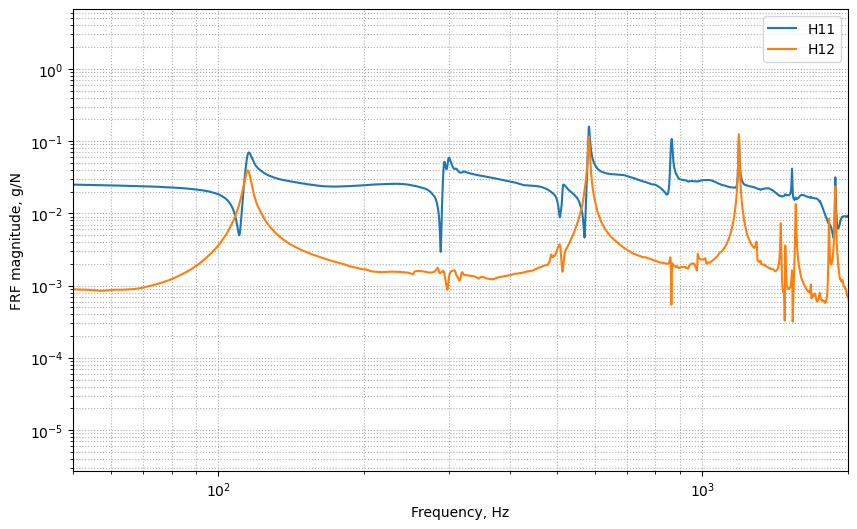

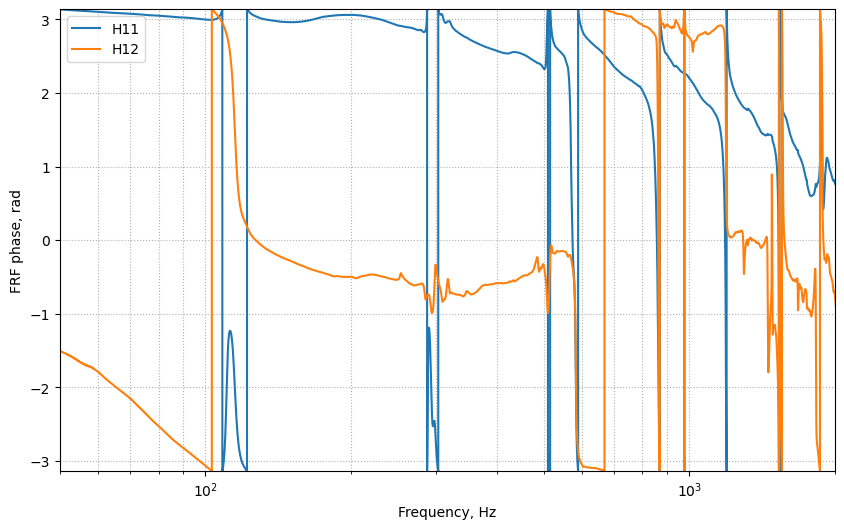

In [37]:
# Read the five repeated impacts for hammer position 1
data_acc1T1 = pd.read_csv('data1/acc1T1.csv', skiprows=3).to_numpy()
data_acc1T2 = pd.read_csv('data1/acc1T2.csv', skiprows=3).to_numpy()
data_acc1T3 = pd.read_csv('data1/acc1T3.csv', skiprows=3).to_numpy()
data_acc1T4 = pd.read_csv('data1/acc1T4.csv', skiprows=3).to_numpy()
data_acc1T5 = pd.read_csv('data1/acc1T5.csv', skiprows=3).to_numpy()

# Get the five force signals at position 1
forces = np.stack((
    data_acc1T1[:, 1],
    data_acc1T2[:, 1],
    data_acc1T3[:, 1],
    data_acc1T4[:, 1],
    data_acc1T5[:, 1]
), axis=-1)

# H11: output acceleration at position 1 (column 4 -> index 3)
accs_11 = np.stack((
    data_acc1T1[:, 3],
    data_acc1T2[:, 3],
    data_acc1T3[:, 3],
    data_acc1T4[:, 3],
    data_acc1T5[:, 3]
), axis=-1)

# H12: output acceleration at position 2 (column 6 -> index 5)
accs_12 = np.stack((
    data_acc1T1[:, 5],
    data_acc1T2[:, 5],
    data_acc1T3[:, 5],
    data_acc1T4[:, 5],
    data_acc1T5[:, 5]
), axis=-1)

force_trigger = 50
beta = 10

def build_processed_signals(forces, accs):
    acc_pad = np.zeros((20 * sf, 5))
    impulse_pad = np.zeros((20 * sf, 5))

    for ii in range(5):
        impulse = forces[:, ii]
        acc = accs[:, ii]

        idx_boolean = impulse > force_trigger
        idx_triggered = np.where(idx_boolean)[0]

        rec_win = np.zeros(len(impulse))
        rec_win[idx_triggered] = 1

        impulse_windowed = np.multiply(impulse, rec_win)

        start_idx = max(idx_triggered[0] - 10, 0)
        impulse_truncated = impulse_windowed[start_idx:]
        acc_truncated = acc[start_idx:]

        t_acc = np.arange(len(acc_truncated)) / sf
        exp_win = np.exp(-beta * t_acc)

        acc_windowed = np.multiply(acc_truncated, exp_win)
        impulse_truncated_exp = np.multiply(impulse_truncated, exp_win)

        pad_after = 20 * sf - len(acc_truncated)
        acc_pad[:, ii] = np.pad(acc_windowed, (0, pad_after), 'constant', constant_values=(0, 0))
        impulse_pad[:, ii] = np.pad(impulse_truncated_exp, (0, pad_after), 'constant', constant_values=(0, 0))

    acc_processed = np.hstack((acc_pad[:, 0], acc_pad[:, 1], acc_pad[:, 2], acc_pad[:, 3], acc_pad[:, 4]))
    impulse_processed = np.hstack((impulse_pad[:, 0], impulse_pad[:, 1], impulse_pad[:, 2], impulse_pad[:, 3], impulse_pad[:, 4]))

    return impulse_processed, acc_processed

# Process H11 and H12
impulse_processed_11, acc_processed_11 = build_processed_signals(forces, accs_11)
impulse_processed_12, acc_processed_12 = build_processed_signals(forces, accs_12)

# Welch PSD/CSD and H1
N_fft = 80 * sf
N_overlap = 0
N_window = 20 * sf

f11, Sxx_11 = signal.welch(
    impulse_processed_11, sf,
    window='boxcar',
    nperseg=N_window,
    noverlap=N_overlap,
    nfft=N_fft
)
_, Sxy_11 = signal.csd(
    impulse_processed_11, acc_processed_11, sf,
    window='boxcar',
    nperseg=N_window,
    noverlap=N_overlap,
    nfft=N_fft
)
H11 = np.divide(Sxy_11, Sxx_11)

f12, Sxx_12 = signal.welch(
    impulse_processed_12, sf,
    window='boxcar',
    nperseg=N_window,
    noverlap=N_overlap,
    nfft=N_fft
)
_, Sxy_12 = signal.csd(
    impulse_processed_12, acc_processed_12, sf,
    window='boxcar',
    nperseg=N_window,
    noverlap=N_overlap,
    nfft=N_fft
)
H12 = np.divide(Sxy_12, Sxx_12)

# Plot amplitude
plt.figure(figsize=(10, 6))
plt.loglog(f11, np.abs(H11), label='H11')
plt.loglog(f12, np.abs(H12), label='H12')
plt.xlim(50, 2000)
plt.xlabel('Frequency, Hz')
plt.ylabel('FRF magnitude, g/N')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.show()

# Plot phase
plt.figure(figsize=(10, 6))
plt.semilogx(f11, np.angle(H11), label='H11')
plt.semilogx(f12, np.angle(H12), label='H12')
plt.xlim(50, 2000)
plt.ylim(-3.14, 3.14)
plt.xlabel('Frequency, Hz')
plt.ylabel('FRF phase, rad')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.show()


# Problem set 3: Modal parameter identification and statistic model updating.


### Exercise 3.1. Natural frequencies and damping ratio

**a**. Use a figure to show the $N$ measurement positions. Calculate the $N$ FRFs and plot them in one figure.

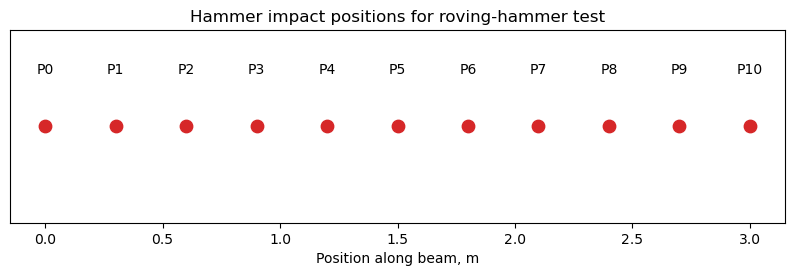

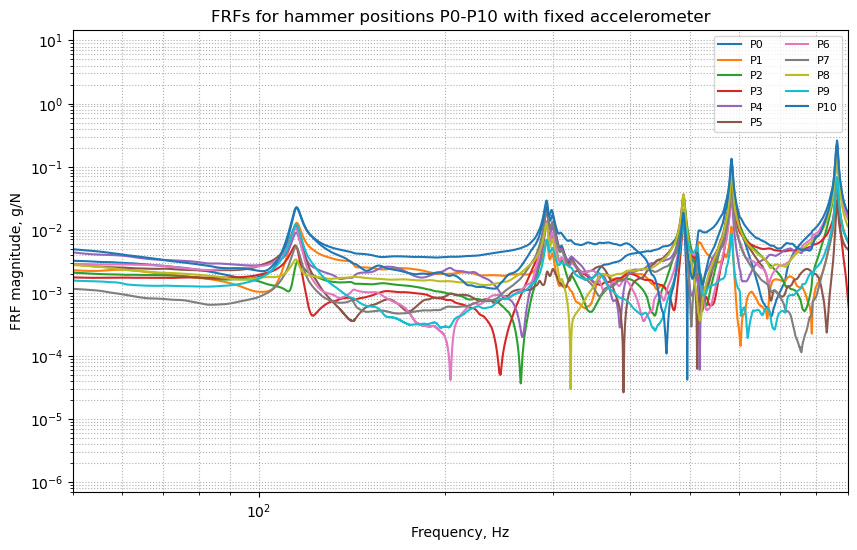

In [38]:
# Hammer positions in data2
positions = list(range(11))   # P0 ... P10

x_positions = np.linspace(0, 3.0, 11)


# Choose fixed accelerometer:
# acc1 -> 3
# acc2 -> 5
# acc3 -> 7
acc_col = 3

sf = 25600
force_trigger = 50
beta = 10
N_window = 20 * sf
N_overlap = 0
N_fft = 80 * sf

def build_frf_for_position(pos, acc_col):
    # Read the five repeated impacts for one hammer position
    repeats = []
    for tt in range(1, 6):
        path = f'data2/P{pos}T{tt}.csv'
        data = pd.read_csv(path, skiprows=4, header=None).to_numpy()
        repeats.append(data)

    # Stack five force and acceleration signals
    forces = np.stack([d[:, 1] for d in repeats], axis=-1)
    accs   = np.stack([d[:, acc_col] for d in repeats], axis=-1)

    # Storage for 20 s padded signals
    acc_pad = np.zeros((20 * sf, 5))
    impulse_pad = np.zeros((20 * sf, 5))

    for ii in range(5):
        impulse = forces[:, ii]
        acc = accs[:, ii]

        idx_boolean = impulse > force_trigger
        idx_triggered = np.where(idx_boolean)[0]

        rec_win = np.zeros(len(impulse))
        rec_win[idx_triggered] = 1

        impulse_windowed = np.multiply(impulse, rec_win)

        start_idx = max(idx_triggered[0] - 10, 0)
        impulse_truncated = impulse_windowed[start_idx:]
        acc_truncated = acc[start_idx:]

        t_acc = np.arange(len(acc_truncated)) / sf
        exp_win = np.exp(-beta * t_acc)

        acc_windowed = np.multiply(acc_truncated, exp_win)
        impulse_truncated_exp = np.multiply(impulse_truncated, exp_win)

        pad_after = 20 * sf - len(acc_truncated)
        acc_pad[:, ii] = np.pad(acc_windowed, (0, pad_after), 'constant')
        impulse_pad[:, ii] = np.pad(impulse_truncated_exp, (0, pad_after), 'constant')

    acc_processed = np.hstack((acc_pad[:, 0], acc_pad[:, 1], acc_pad[:, 2], acc_pad[:, 3], acc_pad[:, 4]))
    impulse_processed = np.hstack((impulse_pad[:, 0], impulse_pad[:, 1], impulse_pad[:, 2], impulse_pad[:, 3], impulse_pad[:, 4]))

    # Welch PSD/CSD and H1
    fxx, Sxx = signal.welch(
        impulse_processed,
        sf,
        window='boxcar',
        nperseg=N_window,
        noverlap=N_overlap,
        nfft=N_fft
    )

    fxy, Sxy = signal.csd(
        impulse_processed,
        acc_processed,
        sf,
        window='boxcar',
        nperseg=N_window,
        noverlap=N_overlap,
        nfft=N_fft
    )

    H1 = np.divide(Sxy, Sxx)
    return fxx, H1

# Compute FRFs for all hammer positions
frfs = []
for pos in positions:
    fxx, H1 = build_frf_for_position(pos, acc_col)
    frfs.append(H1)

frfs = np.array(frfs)

# Plot measurement positions
plt.figure(figsize=(10, 2.5))
plt.scatter(x_positions, np.ones_like(x_positions), s=80, color='tab:red')
for i, xp in enumerate(x_positions):
    plt.text(xp, 1.03, f'P{i}', ha='center')
plt.yticks([])
plt.xlabel('Position along beam, m')
plt.title('Hammer impact positions for roving-hammer test')
plt.show()

# Plot all FRFs in one figure
plt.figure(figsize=(10, 6))
for i, H1 in enumerate(frfs):
    plt.loglog(fxx, np.abs(H1), label=f'P{i}')
plt.xlim(50, 900)
plt.xlabel('Frequency, Hz')
plt.ylabel('FRF magnitude, g/N')
plt.title(r'FRFs for hammer positions P0-P10 with fixed accelerometer')
plt.legend(ncol=2, fontsize=8)
plt.grid(True, which='both', ls=':')
plt.show()


**b**. Identify the first three natural frequencies of the beam bending modes from one of the FRFs you showed in Exercise 3.1.a (choose one as you wish). Compare the first three natural frequencies obtained from the FRF with those calculated from the analytical model (Exercise 1.2.b) and discuss what the possilbe causes for the discrepencies are.

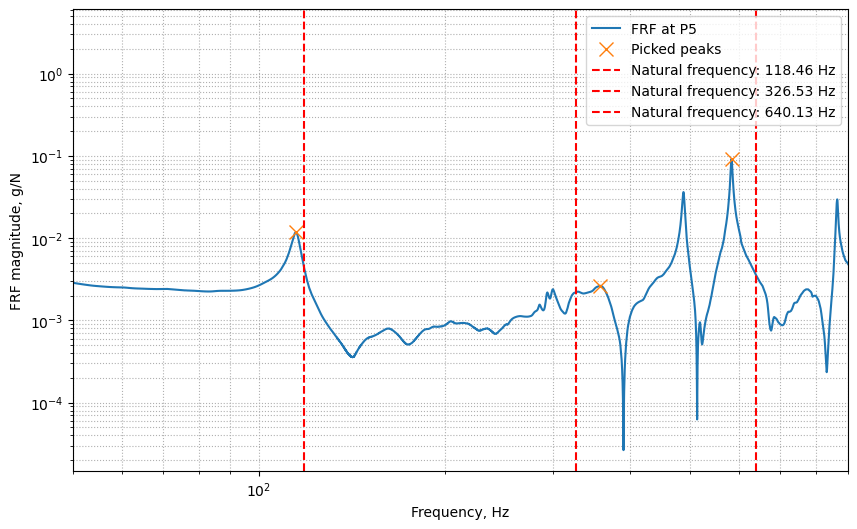

Chosen FRF: P5
First three natural frequencies: 114.88 Hz, 357.62 Hz, 583.27 Hz


In [39]:
# Choose one FRF from 3.1a
frf_idx = 5              # P5, change if another FRF is clearer
frf = np.abs(frfs[frf_idx])

# Frequency bands around the first three bending modes
bands = [(80, 160), (250, 380), (550, 750)]

peak_idx = []
natural_freqs = []

for fmin, fmax in bands:
    mask = (fxx >= fmin) & (fxx <= fmax)
    idx_local = np.argmax(frf[mask])
    idx_global = np.where(mask)[0][idx_local]
    peak_idx.append(idx_global)
    natural_freqs.append(fxx[idx_global])

peak_idx = np.array(peak_idx)
natural_freqs = np.array(natural_freqs)

# Plot the chosen FRF and mark the picked peaks
plt.figure(figsize=(10, 6))
plt.loglog(fxx, frf, label=f'FRF at P{frf_idx}')
plt.plot(fxx[peak_idx], frf[peak_idx], 'x', markersize=10, label='Picked peaks')

# Mark the natural frequencies on the plot
for f in f_n:
    plt.axvline(f, color='r', linestyle='--', label=f'Natural frequency: {f:.2f} Hz')

plt.xlim(50, 900)
plt.xlabel('Frequency, Hz')
plt.ylabel('FRF magnitude, g/N')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.show()

print(f'Chosen FRF: P{frf_idx}')
print(f'First three natural frequencies: {natural_freqs[0]:.2f} Hz, {natural_freqs[1]:.2f} Hz, {natural_freqs[2]:.2f} Hz')


**c**. Estimate the damping ratio of the first three natural frequencies using the same FRF as in Exercise 3.1.b. For this, you can use the half-power bandwidth method.

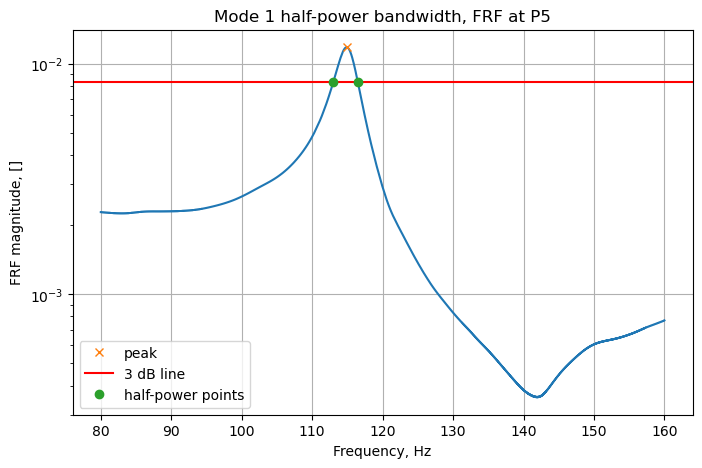

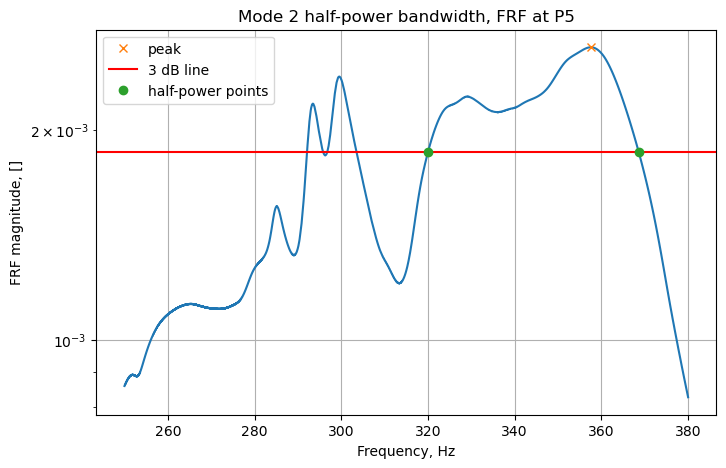

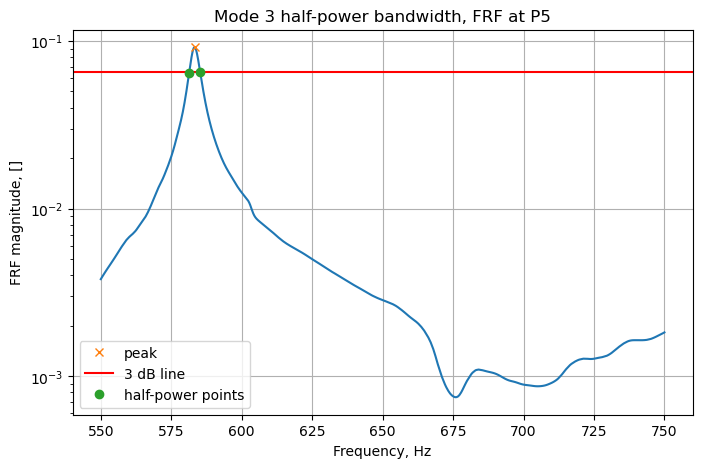

Mode 1:
  natural frequency = 114.88 Hz
  damping ratio     = 0.015125
  corrected damping = 0.001271
Mode 2:
  natural frequency = 357.62 Hz
  damping ratio     = 0.067983
  corrected damping = 0.063533
Mode 3:
  natural frequency = 583.27 Hz
  damping ratio     = 0.003365
  corrected damping = 0.000636


In [40]:
# Choose one FRF from 3.1a
frf_idx = 5                 # example: P5
frf = np.abs(frfs[frf_idx])

# Frequency bands for the first three bending modes
bands = [(80, 160), (250, 380), (550, 750)]

damping_ratios = []
damping_ratios_corrected = []
natural_freqs = []

for i, (fmin, fmax) in enumerate(bands, start=1):
    # Restrict to one mode band
    mask = (fxx >= fmin) & (fxx <= fmax)
    f_band = fxx[mask]
    frf_band = frf[mask]

    # Peak in this band
    peak_local = np.argmax(frf_band)
    f_r = f_band[peak_local]
    natural_freqs.append(f_r)

    # 3 dB level
    peak_3db = frf_band[peak_local] / np.sqrt(2)

    # Same idea as example: difference to half-power line
    diff_3db = -np.abs(frf_band - peak_3db)

    # Left and right half-power points
    left_idx = np.argmax(diff_3db[:peak_local])
    right_idx = peak_local + 1 + np.argmax(diff_3db[peak_local + 1:])

    f_1 = f_band[left_idx]
    f_2 = f_band[right_idx]
    delta_f = f_2 - f_1

    # Damping ratio
    zeta = delta_f / (2 * f_r)
    zeta_c = zeta - beta / (2 * np.pi * f_r)

    damping_ratios.append(zeta)
    damping_ratios_corrected.append(zeta_c)

    # Plot for this mode
    plt.figure(figsize=(8, 5))
    plt.semilogy(f_band, frf_band)
    plt.plot(f_r, frf_band[peak_local], "x", label='peak')
    plt.axhline(y=peak_3db, color='r', linestyle='-', label='3 dB line')
    plt.plot([f_1, f_2], [frf_band[left_idx], frf_band[right_idx]], "o", label='half-power points')
    plt.xlabel('Frequency, Hz')
    plt.ylabel('FRF magnitude, []')
    plt.title(f'Mode {i} half-power bandwidth, FRF at P{frf_idx}')
    plt.legend()
    plt.grid(True)
    plt.show()

# Print results
for i in range(3):
    print(f"Mode {i+1}:")
    print(f"  natural frequency = {natural_freqs[i]:.2f} Hz")
    print(f"  damping ratio     = {damping_ratios[i]:.6f}")
    print(f"  corrected damping = {damping_ratios_corrected[i]:.6f}")


### Exercise 3.2. Mode shapes

**a.** Plot the modal amplitude $a_1$ at the $N$ positions to show the first mode shape. Note that you should scale the modal amplitude $a_1$ so that its maximum amplitude is 100.

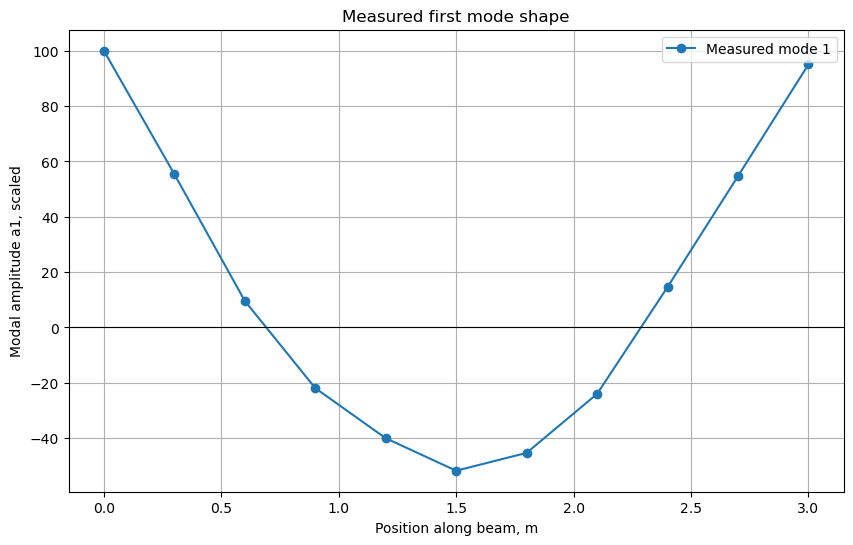

Median first-mode frequency = 114.98 Hz
Median corrected damping ratio = 0.001429


In [41]:
# Mode band
first_mode_band = (80, 160)

n_pos = frfs.shape[0]

f1_each = np.zeros(n_pos)
zeta1_each = np.zeros(n_pos)
H1_peak_each = np.zeros(n_pos, dtype=complex)

for p in range(n_pos):
    Hp = frfs[p]
    Hp_mag = np.abs(Hp)

    mask = (fxx >= first_mode_band[0]) & (fxx <= first_mode_band[1])
    f_band = fxx[mask]
    H_band = Hp[mask]
    H_mag_band = Hp_mag[mask]

    peak_local = np.argmax(H_mag_band)
    peak_global = np.where(mask)[0][peak_local]

    f_r = fxx[peak_global]
    f1_each[p] = f_r
    H1_peak_each[p] = frfs[p, peak_global]

    peak_3db = H_mag_band[peak_local] / np.sqrt(2)

    left_idx = np.argmin(np.abs(H_mag_band[:peak_local] - peak_3db))
    right_idx = peak_local + 1 + np.argmin(np.abs(H_mag_band[peak_local + 1:] - peak_3db))

    f_1 = f_band[left_idx]
    f_2 = f_band[right_idx]

    zeta_raw = (f_2 - f_1) / (2 * f_r)
    zeta_corr = zeta_raw - beta / (2 * np.pi * f_r)

    if zeta_corr <= 0:
        zeta_corr = zeta_raw

    zeta1_each[p] = zeta_corr

# Use one global damping estimate for mode 1
zeta1_global = np.median(zeta1_each)
Q1 = 1 / (2 * zeta1_global)

# Modal amplitude a1 at each position
a1_complex = H1_peak_each / (1j * Q1)
a1_measured = np.real(a1_complex)

# Normalize so max absolute amplitude is 100
mode1_measured = 100 * a1_measured / np.max(np.abs(a1_measured))

# Optional sign convention for plotting
if mode1_measured[0] < 0:
    mode1_measured = -mode1_measured

plt.figure(figsize=(10, 6))
plt.plot(x_positions, mode1_measured, 'o-', label='Measured mode 1')
plt.axhline(0, color='k', linewidth=0.8)
plt.xlabel('Position along beam, m')
plt.ylabel('Modal amplitude a1, scaled')
plt.title('Measured first mode shape')
plt.grid(True)
plt.legend()
plt.show()

print(f'Median first-mode frequency = {np.median(f1_each):.2f} Hz')
print(f'Median corrected damping ratio = {zeta1_global:.6f}')


**b.** Calculate and show the first three analytical mode shapes of a free-free beam. Note that you should scale each mode shape $W_n(x)$ so that its maximum amplitude is 100.

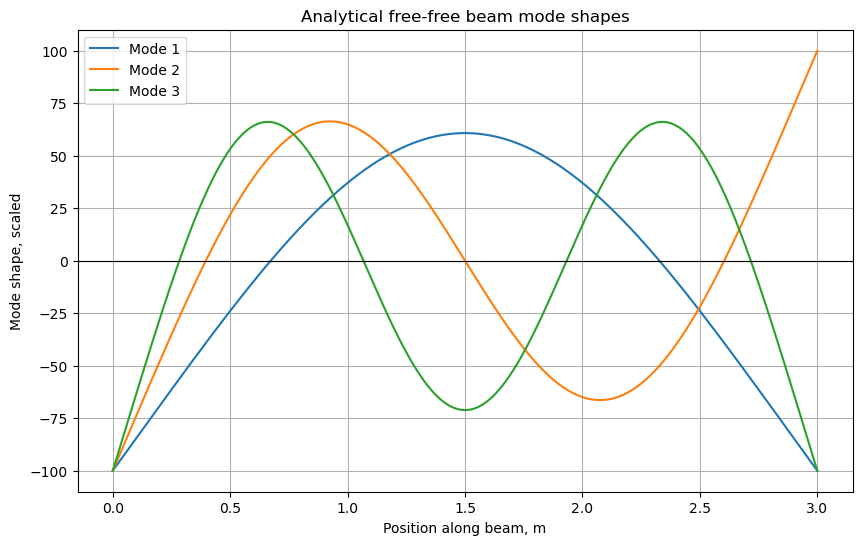

In [42]:
L = 3.0
betaL = np.array([4.730041, 7.853205, 10.995608])

def free_free_mode(betaL_n, x, L):
    beta_n = betaL_n / L
    alpha_n = (np.sin(beta_n * L) - np.sinh(beta_n * L)) / (np.cosh(beta_n * L) - np.cos(beta_n * L))
    W = np.sin(beta_n * x) + np.sinh(beta_n * x) + alpha_n * (np.cos(beta_n * x) + np.cosh(beta_n * x))
    return 100 * W / np.max(np.abs(W))

x_plot = np.linspace(0, L, 400)

mode1_analytic_plot = free_free_mode(betaL[0], x_plot, L)
mode2_analytic_plot = free_free_mode(betaL[1], x_plot, L)
mode3_analytic_plot = free_free_mode(betaL[2], x_plot, L)

# Values at the measurement positions for 3.2c
mode1_analytic = free_free_mode(betaL[0], x_positions, L)

plt.figure(figsize=(10, 6))
plt.plot(x_plot, mode1_analytic_plot, label='Mode 1')
plt.plot(x_plot, mode2_analytic_plot, label='Mode 2')
plt.plot(x_plot, mode3_analytic_plot, label='Mode 3')
plt.axhline(0, color='k', linewidth=0.8)
plt.xlabel('Position along beam, m')
plt.ylabel('Mode shape, scaled')
plt.title('Analytical free-free beam mode shapes')
plt.grid(True)
plt.legend()
plt.show()


**c.** Plot the measured (Exercise 3.2.a) and analytical (Exercise 3.2.b) model shapes for the first mode in one figure. Caculate the Modal Assurance Criterion (MAC) value between the two mode shapes. Explain what this MAC value indicates.

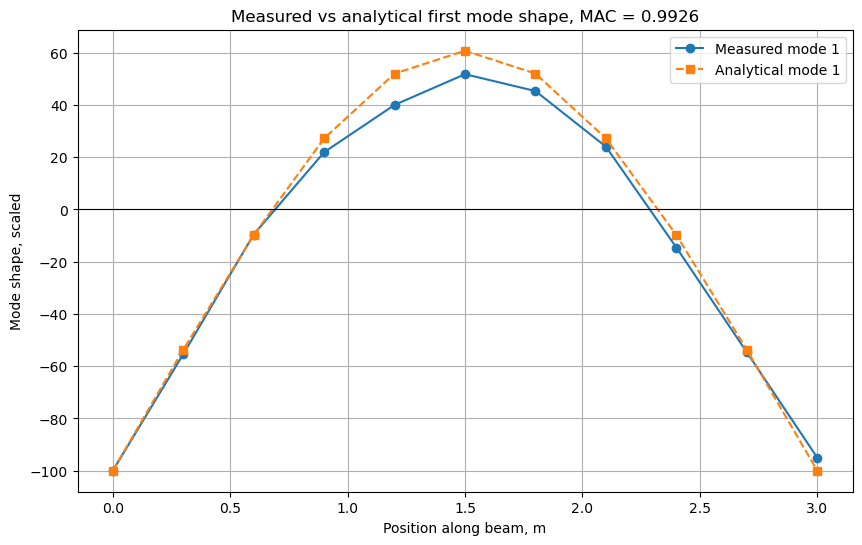

MAC between measured and analytical first mode = 0.9926


In [43]:
# Flip measured mode if needed so the plot matches the analytical orientation
mode1_measured_plot = mode1_measured.copy()
if np.vdot(mode1_measured_plot, mode1_analytic) < 0:
    mode1_measured_plot = -mode1_measured_plot

phi_meas = mode1_measured_plot.astype(complex)
phi_ana = mode1_analytic.astype(complex)

MAC_11 = np.abs(np.vdot(phi_meas, phi_ana))**2 / (np.vdot(phi_meas, phi_meas) * np.vdot(phi_ana, phi_ana))
MAC_11 = np.real(MAC_11)

plt.figure(figsize=(10, 6))
plt.plot(x_positions, mode1_measured_plot, 'o-', label='Measured mode 1')
plt.plot(x_positions, mode1_analytic, 's--', label='Analytical mode 1')
plt.axhline(0, color='k', linewidth=0.8)
plt.xlabel('Position along beam, m')
plt.ylabel('Mode shape, scaled')
plt.title(f'Measured vs analytical first mode shape, MAC = {MAC_11:.4f}')
plt.grid(True)
plt.legend()
plt.show()

print(f'MAC between measured and analytical first mode = {MAC_11:.4f}')


### Exercise 3.3. Analysis of measurement uncertainty ï¼ˆoptionalï¼‰

Compare the FRFs measured with hits at ideal and deviated locations and analyze how the hammer hitting positions may influence the measurement results.

In [44]:
# Your answer